# Eval-трек · Design2Code baseline с единой конвенцией серых плейсхолдеров

Итог обсуждения: тот же baseline (`Qwen2.5-VL-3B-Instruct`), но:

1. **Единая конвенция плейсхолдеров.** Перед рендером — и в эталонном HTML, и в HTML, который
   сгенерировала модель — каждый `<img>` принудительно заменяется на
   `<div class="bg-gray-300 w-full h-48 rounded"></div>`. Никакого `rick.jpg` больше не нужно:
   реальных `<img>` не остаётся ни с одной стороны, сравнение честное независимо от того, что модель
   сама придумала для картинок.
2. **Рендер и метрики — официальные, без замены.** Используем `visual_eval_v3_multi` из
   [`NoviScl/Design2Code`](https://github.com/NoviScl/Design2Code) как есть (Block-Match, Text,
   Position, Color, CLIP) — это тот же код, что и в статье.
3. **Известный баг апстрима пропатчен.** В `metrics/visual_score.py` на момент подготовки этого
   ноутбука есть несогласованные отступы вокруг `elif` внутри `visual_eval_v3_multi`
   (`IndentationError` при импорте) — это опечатка в самом репозитории, не наша логика. Патчим только
   пробелы, ниже это отдельная прозрачная ячейка.
4. **10 примеров из Design2Code**, для каждого — три картинки рядом: рендер эталона (с плейсхолдерами),
   рендер предсказания модели (с плейсхолдерами), и оригинальный скриншот из датасета как есть (без
   нашей подмены — для наглядности, что было "до").

⚠️ Про Tailwind-классы в плейсхолдере: эталонный HTML в Design2Code уже несёт весь Tailwind CSS
предкомпилированным внутри `<style>`, так что `bg-gray-300`/`w-full`/`h-48` там просто сработают. Модель
на 3B, скорее всего, Tailwind с собой не потащит — тогда классы без стилей ничего не дадут, и плейсхолдер
схлопнется в невидимый div. Чтобы серый блок был виден **независимо от того, есть у модели Tailwind или
нет**, к тем же классам добавлен inline-`style` с эквивалентными значениями (`#d1d5db`, `12rem` и т.д.) —
это чисто defensive-мера, сами классы оставлены как просили.


## 1. Установка зависимостей

In [ ]:
!pip install --upgrade pillow

In [1]:
#@title Проверка GPU
!nvidia-smi --query-gpu=name,memory.total --format=csv


name, memory.total [MiB]
Tesla T4, 15360 MiB


In [2]:
#@title pip-пакеты
!pip install -q -U transformers accelerate qwen-vl-utils datasets huggingface_hub \
    pandas tqdm matplotlib playwright beautifulsoup4 colormath scipy scikit-learn joblib openai-clip


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 770.3/770.3 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.6/676.6 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
#@title Браузер для Playwright (нужен официальному рендеру Design2Code)
!playwright install --with-deps chromium


Installing dependencies...
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [100 kB]
Get:10 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,838 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:13 https://ppa.launchpadc

In [4]:
import os

if not os.path.exists("/content/Design2Code"):
    !git clone -q https://github.com/NoviScl/Design2Code.git /content/Design2Code

!pip install -q -e /content/Design2Code --no-deps


  Preparing metadata (setup.py) ... done


In [5]:
_vs_path = "/content/Design2Code/Design2Code/metrics/visual_score.py"
with open(_vs_path, "r") as _f:
    _src = _f.read()

_broken = '''    for k, predict_blocks in enumerate(predict_blocks_list):
         if len(predict_blocks) == 0:
                print("[Warning] No detected blocks in: ", predict_img_list[k])
                final_clip_score = calculate_clip_similarity_with_blocks(predict_img_list[k], original_img, predict_blocks, original_blocks)
                return_score_list.append([0.0, 0.2 * final_clip_score, (0.0, 0.0, 0.0, 0.0, final_clip_score)])
                continue
            elif len(original_blocks) == 0:
                print("[Warning] No detected blocks in: ", original_img)
                final_clip_score = calculate_clip_similarity_with_blocks(predict_img_list[k], original_img, predict_blocks, original_blocks)
                return_score_list.append([0.0, 0.2 * final_clip_score, (0.0, 0.0, 0.0, 0.0, final_clip_score)])
                continue'''

_fixed = '''    for k, predict_blocks in enumerate(predict_blocks_list):
        if len(predict_blocks) == 0:
            print("[Warning] No detected blocks in: ", predict_img_list[k])
            final_clip_score = calculate_clip_similarity_with_blocks(predict_img_list[k], original_img, predict_blocks, original_blocks)
            return_score_list.append([0.0, 0.2 * final_clip_score, (0.0, 0.0, 0.0, 0.0, final_clip_score)])
            continue
        elif len(original_blocks) == 0:
            print("[Warning] No detected blocks in: ", original_img)
            final_clip_score = calculate_clip_similarity_with_blocks(predict_img_list[k], original_img, predict_blocks, original_blocks)
            return_score_list.append([0.0, 0.2 * final_clip_score, (0.0, 0.0, 0.0, 0.0, final_clip_score)])
            continue'''

if _broken in _src:
    _src = _src.replace(_broken, _fixed)
    with open(_vs_path, "w") as _f:
        _f.write(_src)
    print("Патч применён: поправили отступы в visual_eval_v3_multi.")
else:
    print("Строка с багом не найдена (возможно, уже пофикшено в апстриме) — патч пропущен.")


Патч применён: поправили отступы в visual_eval_v3_multi.


## 2. Конфиг

In [6]:
import json, re, random
from pathlib import Path

MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
MAX_NEW_TOKENS = 2048

HF_DATASET = "SALT-NLP/Design2Code-hf"
N_SAMPLES = 10
SEED = 0

PLACEHOLDER_CLASSES = ["bg-gray-300", "w-full", "h-48", "rounded"]
PLACEHOLDER_STYLE = "background-color:#d1d5db;width:100%;height:12rem;border-radius:0.5rem;display:block;"

WORK_DIR = Path("/content/design2code_eval_v2")
WORK_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
device = "cuda"
print("Config OK. Work dir:", WORK_DIR)


Config OK. Work dir: /content/design2code_eval_v2


## 3. Датасет

README.md:   0%|          | 0.00/827 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 77.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/484 [00:00<?, ? examples/s]

Всего примеров в Design2Code: 484
Взяли в подвыборку: 10


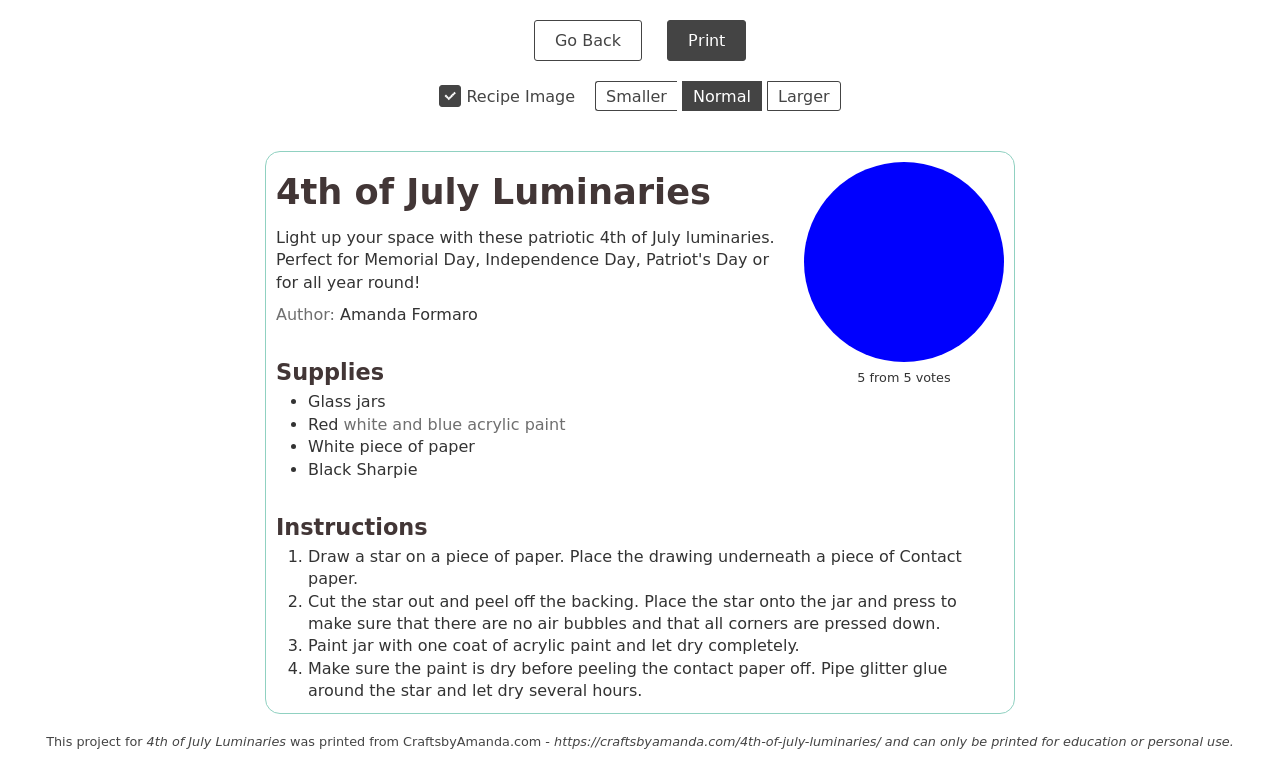

In [7]:
from datasets import load_dataset

ds_full = load_dataset(HF_DATASET, split="train")
print("Всего примеров в Design2Code:", len(ds_full))

ds = ds_full.shuffle(seed=SEED).select(range(min(N_SAMPLES, len(ds_full))))
print("Взяли в подвыборку:", len(ds))
ds[0]["image"]


## 4. Модель Qwen2.5-VL-3B-Instruct

In [8]:
import torch
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID, torch_dtype=torch.bfloat16, device_map="auto"
)
processor = AutoProcessor.from_pretrained(MODEL_ID)
model.eval()
print("Модель загружена:", MODEL_ID)


config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Модель загружена: Qwen/Qwen2.5-VL-3B-Instruct


In [9]:
PROMPT = (
    "You are an expert front-end developer. Look at this webpage screenshot and "
    "write a SINGLE self-contained HTML file (inline <style>, no external CSS/JS/fonts, "
    "no network requests) that reproduces the layout, text, and colors as closely as "
    "possible. Use plain gray placeholder boxes instead of any real images. "
    "Output ONLY the raw HTML code, with no explanation and no markdown code fences."
)

def extract_html(text: str) -> str:
    # Достаёт HTML из ответа модели: убирает markdown-ограждения и текст до <!doctype>/<html>
    m = re.search(r"```(?:html)?\s*(.*?)```", text, re.DOTALL | re.IGNORECASE)
    if m:
        text = m.group(1)
    low = text.lower()
    start = low.find("<!doctype")
    if start == -1:
        start = low.find("<html")
    if start != -1:
        text = text[start:]
    return text.strip()


@torch.no_grad()
def generate_html(image) -> str:
    torch.cuda.empty_cache()
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": PROMPT},
            ],
        }
    ]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text], images=image_inputs, videos=video_inputs,
        padding=True, return_tensors="pt",
    ).to(model.device)

    generated_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)
    trimmed = [out[len(inp):] for inp, out in zip(inputs.input_ids, generated_ids)]
    output_text = processor.batch_decode(
        trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]
    del inputs, generated_ids, trimmed
    torch.cuda.empty_cache()
    return extract_html(output_text)


## 5. Единая замена `<img>` на серый плейсхолдер

Применяется к **обеим** сторонам (эталон и предсказание) одинаково, до какого-либо рендера.

In [10]:
from bs4 import BeautifulSoup

def replace_images_with_placeholder(html_text: str):
    soup = BeautifulSoup(html_text, "html.parser")
    n_replaced = 0
    for img_tag in soup.find_all("img"):
        new_div = soup.new_tag("div")
        new_div["class"] = PLACEHOLDER_CLASSES
        new_div["style"] = PLACEHOLDER_STYLE
        img_tag.replace_with(new_div)
        n_replaced += 1
    return str(soup), n_replaced


## 6. Генерация предсказаний + подготовка файлов для рендера

In [11]:
from tqdm.auto import tqdm

samples = []

for i in tqdm(range(len(ds)), desc="Generating + preparing HTML"):
    sample_dir = WORK_DIR / f"sample_{i:04d}"
    sample_dir.mkdir(exist_ok=True)

    ref_image = ds[i]["image"].convert("RGB")

    ref_html_raw = ds[i]["text"]
    ref_html_clean, ref_n_img = replace_images_with_placeholder(ref_html_raw)
    ref_html_path = sample_dir / "ref.html"
    ref_html_path.write_text(ref_html_clean, encoding="utf-8")

    entry = {
        "idx": i,
        "sample_dir": str(sample_dir.resolve()),
        "ref_html_path": str(ref_html_path.resolve()),
        "ref_png_path": str((sample_dir / "ref.png").resolve()),
        "orig_dataset_image": ref_image,
        "ref_n_img_replaced": ref_n_img,
    }

    try:
        pred_html_raw = generate_html(ref_image)
    except Exception as e:
        entry["status"] = f"generation_error: {e}"
        samples.append(entry)
        continue

    pred_html_clean, pred_n_img = replace_images_with_placeholder(pred_html_raw)
    pred_html_path = sample_dir / "pred.html"
    pred_html_path.write_text(pred_html_clean, encoding="utf-8")

    entry.update({
        "pred_html_path": str(pred_html_path.resolve()),
        "pred_png_path": str((sample_dir / "pred.png").resolve()),
        "pred_n_img_replaced": pred_n_img,
        "status": "generated",
    })
    samples.append(entry)

n_ok = sum(1 for s in samples if s["status"] == "generated")
print(f"Сгенерировано и подготовлено: {n_ok} / {len(samples)}")


Generating + preparing HTML:   0%|          | 0/10 [00:00<?, ?it/s]

Сгенерировано и подготовлено: 6 / 10


## 7. Официальный рендер + метрики Design2Code

`visual_eval_v3_multi` рендерит **и** эталон, **и** предсказание сам (их `screenshot_single.py`,
Playwright) и тут же считает Block-Match / Text / Position / Color / CLIP по сматченным блокам.
`pred.png` / `ref.png`, которые он создаёт, — это ровно те картинки, по которым посчитаны метрики,
их же используем дальше для визуального сравнения (§8).

In [12]:
import sys, os
if "/content/Design2Code" not in sys.path:
    sys.path.insert(0, "/content/Design2Code")

from Design2Code.metrics.visual_score import visual_eval_v3_multi

INNER_PKG_DIR = "/content/Design2Code/Design2Code"

_orig_cwd = os.getcwd()
os.chdir(INNER_PKG_DIR)
try:
    for s in tqdm([s for s in samples if s["status"] == "generated"], desc="Official Design2Code metrics"):
        try:
            input_list = [[s["pred_html_path"]], s["ref_html_path"]]
            result = visual_eval_v3_multi(input_list, debug=False)
            _, final_score, multi = result[0]
            block_match, text_score, position, color, clip_d2c = multi
            s.update({
                "status": "scored",
                "block_match": block_match,
                "text": text_score,
                "position": position,
                "color": color,
                "clip_d2c": clip_d2c,
                "final_score": final_score,
            })
        except Exception as e:
            s["status"] = f"metric_error: {e}"
finally:
    os.chdir(_orig_cwd)

n_scored = sum(1 for s in samples if s["status"] == "scored")
print(f"Оценено официальными метриками: {n_scored} / {len(samples)}")


100%|███████████████████████████████████████| 338M/338M [00:05<00:00, 67.4MiB/s]


Official Design2Code metrics:   0%|          | 0/6 [00:00<?, ?it/s]

Оценено официальными метриками: 6 / 10


In [13]:
import pandas as pd

metrics_df = pd.DataFrame([
    {
        "idx": s["idx"],
        "status": s["status"],
        "block_match": s.get("block_match"),
        "text": s.get("text"),
        "position": s.get("position"),
        "color": s.get("color"),
        "clip_d2c": s.get("clip_d2c"),
        "final_score": s.get("final_score"),
        "ref_img_replaced": s.get("ref_n_img_replaced"),
        "pred_img_replaced": s.get("pred_n_img_replaced"),
    }
    for s in samples
])
metrics_path = WORK_DIR / "results.csv"
metrics_df.to_csv(metrics_path, index=False)

print(f"Модель: {MODEL_ID}")
ok_df = metrics_df[metrics_df["status"] == "scored"]
print(f"Успешно посчитано: {len(ok_df)} / {len(metrics_df)}")
print()
if len(ok_df) > 0:
    print(ok_df[["block_match", "text", "position", "color", "clip_d2c", "final_score"]].mean().to_string())
metrics_df


Модель: Qwen/Qwen2.5-VL-3B-Instruct
Успешно посчитано: 6 / 10

block_match    0.739451
text           0.986732
position       0.817424
color          0.724662
clip_d2c       0.875895
final_score    0.828833


,idx,status,block_match,text,position,color,clip_d2c,final_score,ref_img_replaced,pred_img_replaced
0,0,scored,0.971421,0.985951,0.816482,0.771882,0.906250,0.890397,1,1.0
1,1,scored,0.997746,0.997500,0.814356,0.854071,0.881836,0.909102,2,0.0
2,2,generation_error: CUDA out of memory. Tried to...,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN
3,3,scored,0.159524,0.958824,0.789185,0.564963,0.930664,0.680632,1,0.0
4,4,generation_error: CUDA out of memory. Tried to...,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN
5,5,scored,0.333808,1.000000,0.871240,0.779166,0.840820,0.765007,0,3.0
6,6,scored,0.986113,0.988376,0.893290,0.962172,0.887207,0.943432,1,0.0
7,7,generation_error: CUDA out of memory. Tried to...,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN
8,8,generation_error: CUDA out of memory. Tried to...,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
9,9,scored,0.988094,0.989744,0.719991,0.415719,0.808594,0.784428,2,0.0


## 8. Визуальное сравнение: эталон / предсказание / оригинал из датасета

Три колонки на каждый из 10 сэмплов:
- **REF (плейсхолдеры)** — рендер эталонного HTML после замены `<img>` → серый div
- **PRED (плейсхолдеры)** — рендер HTML модели после той же замены
- **ORIGINAL (датасет)** — исходный скриншот из Design2Code как есть, без нашей подмены (для наглядности,
  что было "до")

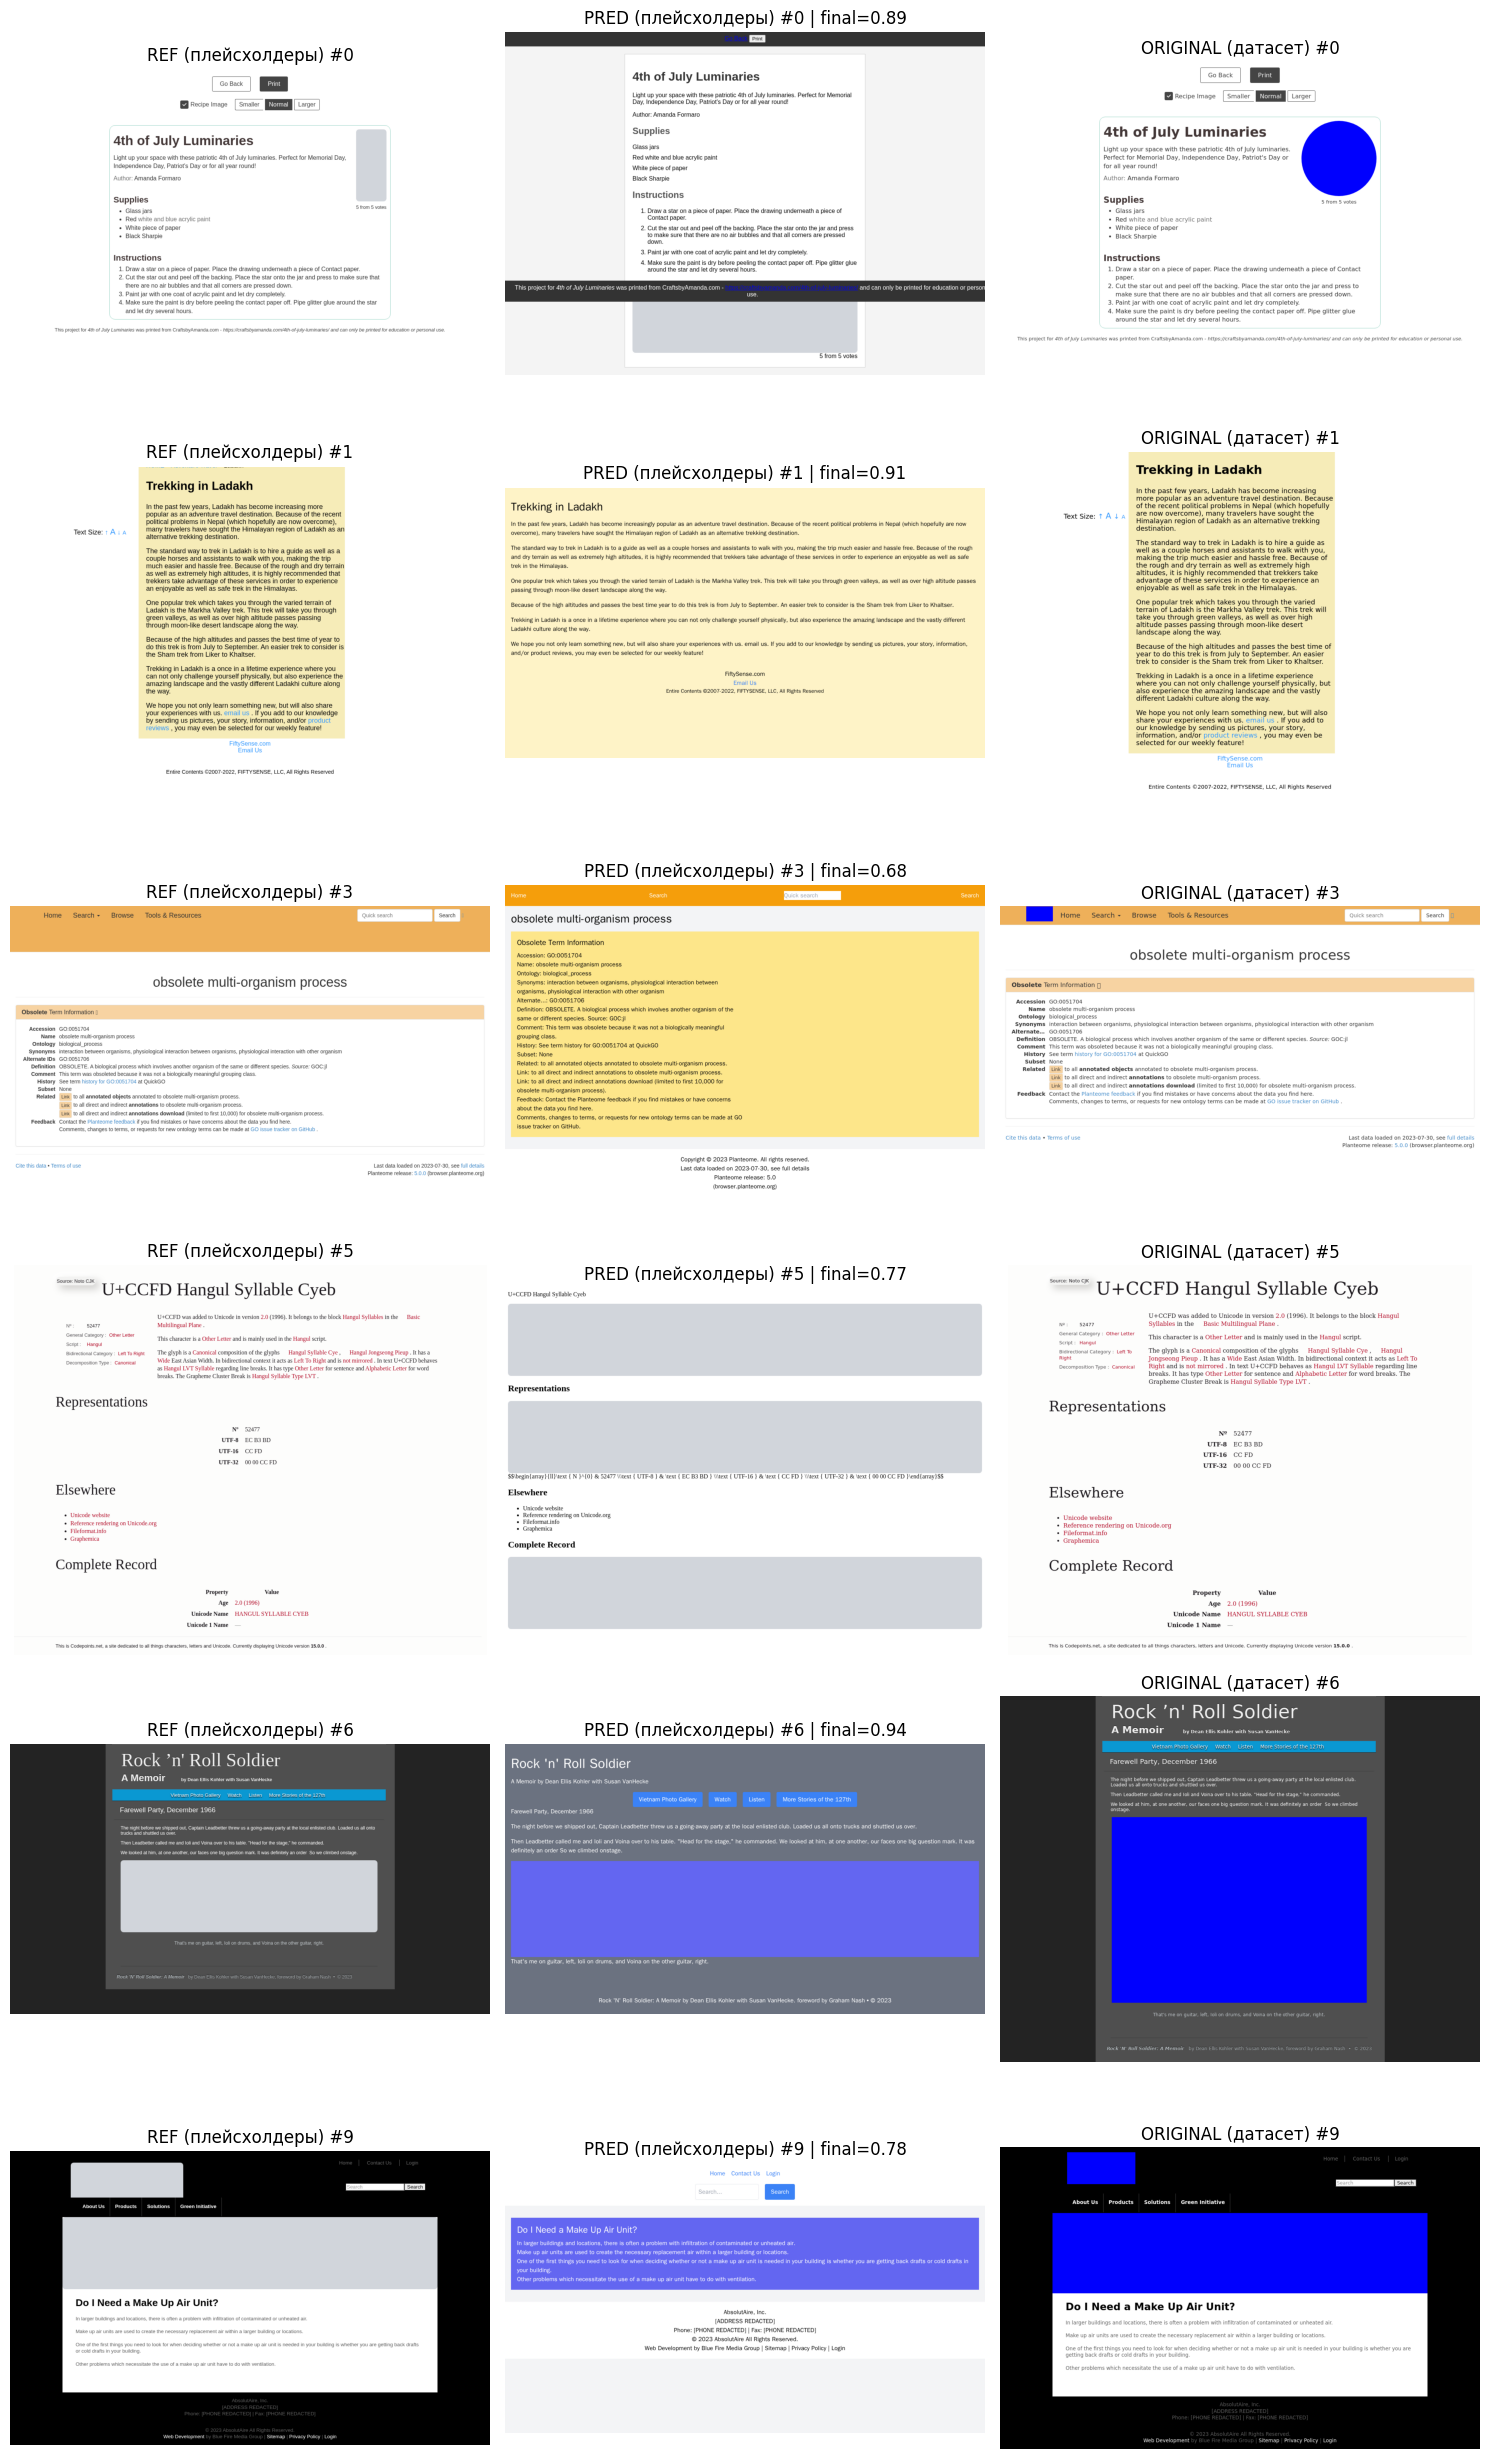

In [14]:
import matplotlib.pyplot as plt
from PIL import Image

scored_samples = [s for s in samples if s["status"] == "scored"]
n = len(scored_samples)

fig, axes = plt.subplots(n, 3, figsize=(15, 4.2 * n))
if n == 1:
    axes = [axes]

for row, s in zip(axes, scored_samples):
    orig_img = s["orig_dataset_image"]
    try:
        ref_img = Image.open(s["ref_png_path"])
    except Exception:
        ref_img = None
    try:
        pred_img = Image.open(s["pred_png_path"])
    except Exception:
        pred_img = None

    row[0].imshow(ref_img) if ref_img else row[0].text(0.5, 0.5, "render failed", ha="center")
    row[0].set_title(f"REF (плейсхолдеры) #{s['idx']}")
    row[0].axis("off")

    row[1].imshow(pred_img) if pred_img else row[1].text(0.5, 0.5, "render failed", ha="center")
    row[1].set_title(f"PRED (плейсхолдеры) #{s['idx']} | final={s.get('final_score', 0):.2f}")
    row[1].axis("off")

    row[2].imshow(orig_img)
    row[2].set_title(f"ORIGINAL (датасет) #{s['idx']}")
    row[2].axis("off")

plt.tight_layout()
plt.show()
